In [1]:
## Importing all the necesary libraries

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

0 -> Fake news
1 -> Real news

In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [5]:
## Loading the dataset 

data = pd.read_csv("news_fake_real_dataset.csv")

In [6]:
data.shape

(44898, 5)

In [7]:
data.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [8]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [10]:
data["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

In [11]:
data["label"].value_counts(normalize=True) * 100

label
0    52.298543
1    47.701457
Name: proportion, dtype: float64

Visualization

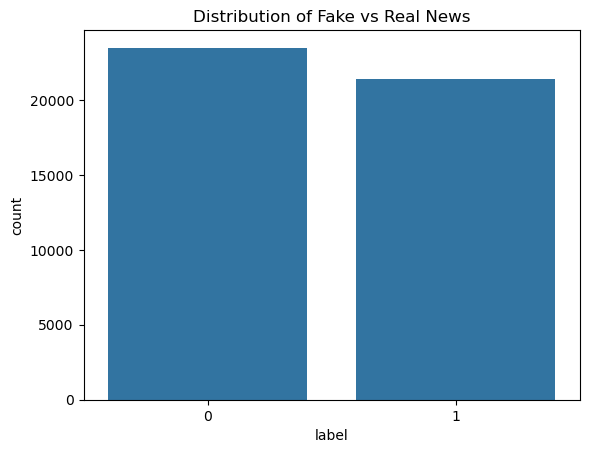

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=data["label"])
plt.title("Distribution of Fake vs Real News")
plt.show()

In [13]:
data["content"] = (
    data["title"] + " " +
    data["subject"] + " " +
    data["text"]
)

In [14]:
data = data[['content', 'label']]

In [15]:
data.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


Text Preprocessing

In [16]:

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

data["content"] = data["content"].apply(clean_text)

Train-Test split

In [17]:
X = data["content"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Implementing TfIDF VEctorizer

In [18]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Model Training 

In [20]:
model = LogisticRegression()
model.fit(X_train_tfidf,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
## Evalutaion and prdiction 

Train_prediction = model.predict(X_train_tfidf)
Train_score = accuracy_score(Train_prediction,y_train)
Train_score

0.9958516621192717

In [23]:
Test_prediction = model.predict(X_test_tfidf)
Test_score = accuracy_score(Test_prediction,y_test)
Test_score

0.9944320712694877

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, Test_prediction))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [27]:
from sklearn.metrics import confusion_matrix

Mat = confusion_matrix(y_test,Test_prediction)
Mat

array([[4664,   32],
       [  18, 4266]])

In [30]:
## Making a prdictve system 

input_news = """
Breaking: Scientists discover a new energy source...
"""

input_data = ([input_news])

input_vector = tfidf.transform(input_data)

prediction = model.predict(input_vector)

confidence = max(model.predict_proba(input_vector)[0]) * 100

if prediction[0] == 1:
    print(f"The news is likely real ({confidence:.2f}% confidence)")
else:
    print(f"The news is likely fake ({confidence:.2f}% confidence)")




The news is likely fake (87.08% confidence)
